<a href="https://colab.research.google.com/github/Anushka-garg04/AIML-bootcamp-projects/blob/main/Grade_system_workflow_using_Agentic_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 17.9 MB/s eta 0:00:00


In [3]:
from pypdf import PdfReader

pdf_file_path = '/content/Project_1_Problem Statement.pdf'

reader = PdfReader(pdf_file_path)
text_content = ""
for page in reader.pages:
    text_content += page.extract_text() + "\n"

print("Extracted text from the PDF:")
print(text_content[:1000]) # Print first 1000 characters to avoid overwhelming output

Extracted text from the PDF:
LLOYD INSTITUTE OF ENGINEERING & TECHNOLOGY 
(Affiliated to Dr. A.P.J. Abdul Kalam Technical University & Approved by AICTE, New Delhi) 
Plot No. 3, Knowledge Park II, Greater Noida, Uttar Pradesh – 201306 
 
 
 
 
1 
 
 
Summer Training: ML and Agentic AI 
Project #1 Grade system workflow using Agentic AI 
Problem Statement 
During the 25-day Machine Learning and Agentic AI Training Program , students participate 
in a daily MCQ quiz conducted through Google Forms. After each quiz, the marks of all 
students are downloaded and stored as separate files. As the number of quizzes increases, 
manually combining marks, calculating cumulative scores, computing module -wise and 
overall percentiles, assigning grades, generating grade cards, and sending performance 
reports to students becomes a time-consuming and error-prone process. 
Therefore, there is a need to develop an Automated Training Performance M anagement 
System that can automatically detect newly ad

In [5]:
import pandas as pd

excel_file_path = '/content/sample data set.xlsx'
df_quiz_data = pd.read_excel(excel_file_path)

print("First 5 rows of the quiz data:")
display(df_quiz_data.head())

First 5 rows of the quiz data:


,Timestamp,Username,Total score,Name
0,2026/06/14 9:14:31 PM GMT+5:30,jagat.kumar@liet.in,6.00 / 15,Jagat Kumar
1,2026/06/15 12:43:38 PM GMT+5:30,satyanshrawatbtech23-27@liet.in,11.00 / 15,Satyansh Rawat
2,2026/06/15 12:43:42 PM GMT+5:30,sakshichauhanbtech23-27@liet.in,14.00 / 15,Sakshi Chauhan
3,2026/06/15 12:43:54 PM GMT+5:30,anushkagarg2004@gmail.com,13.00 / 15,Anushka garg
4,2026/06/15 2:40:57 PM GMT+5:30,alok_kumar@liet.in,1.00 / 15,ALOK


In [6]:
import numpy as np

def extract_score(score_str):
    if isinstance(score_str, str) and '/' in score_str:
        try:
            return float(score_str.split('/')[0].strip())
        except ValueError:
            return np.nan
    return np.nan

df_quiz_data['Score'] = df_quiz_data['Total score'].apply(extract_score)

print("DataFrame after extracting numeric score:")
display(df_quiz_data.head())
df_quiz_data.info()

DataFrame after extracting numeric score:


,Timestamp,Username,Total score,Name,Score
0,2026/06/14 9:14:31 PM GMT+5:30,jagat.kumar@liet.in,6.00 / 15,Jagat Kumar,6.0
1,2026/06/15 12:43:38 PM GMT+5:30,satyanshrawatbtech23-27@liet.in,11.00 / 15,Satyansh Rawat,11.0
2,2026/06/15 12:43:42 PM GMT+5:30,sakshichauhanbtech23-27@liet.in,14.00 / 15,Sakshi Chauhan,14.0
3,2026/06/15 12:43:54 PM GMT+5:30,anushkagarg2004@gmail.com,13.00 / 15,Anushka garg,13.0
4,2026/06/15 2:40:57 PM GMT+5:30,alok_kumar@liet.in,1.00 / 15,ALOK,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    25 non-null     object 
 1   Username     25 non-null     object 
 2   Total score  25 non-null     object 
 3   Name         25 non-null     object 
 4   Score        25 non-null     float64
dtypes: float64(1), object(4)
memory usage: 1.1+ KB


In [7]:
def extract_max_score(score_str):
    if isinstance(score_str, str) and '/' in score_str:
        try:
            return float(score_str.split('/')[1].strip())
        except ValueError:
            return np.nan
    return np.nan

# Assuming the maximum score is consistent across all entries
max_score = df_quiz_data['Total score'].apply(extract_max_score).mode()[0]
print(f"Maximum possible score: {max_score}")

df_quiz_data['Percentage Score'] = (df_quiz_data['Score'] / max_score) * 100

print("\nDescriptive statistics for scores:")
display(df_quiz_data['Score'].describe())

print("\nDescriptive statistics for percentage scores:")
display(df_quiz_data['Percentage Score'].describe())

print("\nDataFrame with Percentage Score:")
display(df_quiz_data.head())

Maximum possible score: 15.0

Descriptive statistics for scores:


,Score
count,25.000000
mean,12.320000
std,3.287856
min,1.000000
25%,12.000000
50%,13.000000
75%,14.000000
max,15.000000



Descriptive statistics for percentage scores:


,Percentage Score
count,25.000000
mean,82.133333
std,21.919043
min,6.666667
25%,80.000000
50%,86.666667
75%,93.333333
max,100.000000



DataFrame with Percentage Score:


,Timestamp,Username,Total score,Name,Score,Percentage Score
0,2026/06/14 9:14:31 PM GMT+5:30,jagat.kumar@liet.in,6.00 / 15,Jagat Kumar,6.0,40.000000
1,2026/06/15 12:43:38 PM GMT+5:30,satyanshrawatbtech23-27@liet.in,11.00 / 15,Satyansh Rawat,11.0,73.333333
2,2026/06/15 12:43:42 PM GMT+5:30,sakshichauhanbtech23-27@liet.in,14.00 / 15,Sakshi Chauhan,14.0,93.333333
3,2026/06/15 12:43:54 PM GMT+5:30,anushkagarg2004@gmail.com,13.00 / 15,Anushka garg,13.0,86.666667
4,2026/06/15 2:40:57 PM GMT+5:30,alok_kumar@liet.in,1.00 / 15,ALOK,1.0,6.666667


In [8]:
def assign_grade(percentage_score):
    if percentage_score >= 90:
        return 'A'
    elif percentage_score >= 80:
        return 'B'
    elif percentage_score >= 70:
        return 'C'
    elif percentage_score >= 60:
        return 'D'
    else:
        return 'F'

df_quiz_data['Grade'] = df_quiz_data['Percentage Score'].apply(assign_grade)

print("DataFrame with assigned grades:")
display(df_quiz_data.head())

print("\nDistribution of Grades:")
display(df_quiz_data['Grade'].value_counts())

DataFrame with assigned grades:


,Timestamp,Username,Total score,Name,Score,Percentage Score,Grade
0,2026/06/14 9:14:31 PM GMT+5:30,jagat.kumar@liet.in,6.00 / 15,Jagat Kumar,6.0,40.000000,F
1,2026/06/15 12:43:38 PM GMT+5:30,satyanshrawatbtech23-27@liet.in,11.00 / 15,Satyansh Rawat,11.0,73.333333,C
2,2026/06/15 12:43:42 PM GMT+5:30,sakshichauhanbtech23-27@liet.in,14.00 / 15,Sakshi Chauhan,14.0,93.333333,A
3,2026/06/15 12:43:54 PM GMT+5:30,anushkagarg2004@gmail.com,13.00 / 15,Anushka garg,13.0,86.666667,B
4,2026/06/15 2:40:57 PM GMT+5:30,alok_kumar@liet.in,1.00 / 15,ALOK,1.0,6.666667,F



Distribution of Grades:


,count
Grade,
A,12
B,7
D,3
F,2
C,1


In [9]:
df_quiz_data['Percentile Rank'] = df_quiz_data['Percentage Score'].rank(pct=True) * 100

print("DataFrame with Percentile Rank:")
display(df_quiz_data.head())

print("\nDescriptive statistics for Percentile Rank:")
display(df_quiz_data['Percentile Rank'].describe())

DataFrame with Percentile Rank:


,Timestamp,Username,Total score,Name,Score,Percentage Score,Grade,Percentile Rank
0,2026/06/14 9:14:31 PM GMT+5:30,jagat.kumar@liet.in,6.00 / 15,Jagat Kumar,6.0,40.000000,F,8.0
1,2026/06/15 12:43:38 PM GMT+5:30,satyanshrawatbtech23-27@liet.in,11.00 / 15,Satyansh Rawat,11.0,73.333333,C,24.0
2,2026/06/15 12:43:42 PM GMT+5:30,sakshichauhanbtech23-27@liet.in,14.00 / 15,Sakshi Chauhan,14.0,93.333333,A,66.0
3,2026/06/15 12:43:54 PM GMT+5:30,anushkagarg2004@gmail.com,13.00 / 15,Anushka garg,13.0,86.666667,B,46.0
4,2026/06/15 2:40:57 PM GMT+5:30,alok_kumar@liet.in,1.00 / 15,ALOK,1.0,6.666667,F,4.0



Descriptive statistics for Percentile Rank:


,Percentile Rank
count,25.000000
mean,52.000000
std,28.953986
min,4.000000
25%,32.000000
50%,46.000000
75%,66.000000
max,90.000000


In [10]:
print("Student Performance Report (Sorted by Percentage Score):")
display(df_quiz_data.sort_values(by='Percentage Score', ascending=False).reset_index(drop=True))

print("\nSummary of Grades:")
display(df_quiz_data['Grade'].value_counts().sort_index())

print("\nSummary of Scores:")
display(df_quiz_data[['Score', 'Percentage Score', 'Percentile Rank']].describe())

Student Performance Report (Sorted by Percentage Score):


,Timestamp,Username,Total score,Name,Score,Percentage Score,Grade,Percentile Rank
0,2026/06/15 2:47:23 PM GMT+5:30,mohitkumar746185@gmail.com,15.00 / 15,Mohit kumar,15.0,100.000000,A,90.0
1,2026/06/15 2:44:37 PM GMT+5:30,nileshsarkarbtech23-27@liet.in,15.00 / 15,Nilesh sarkar,15.0,100.000000,A,90.0
2,2026/06/15 3:14:23 PM GMT+5:30,kanak.gup1234@gmail.com,15.00 / 15,Kanak Gupta,15.0,100.000000,A,90.0
3,2026/06/15 4:33:19 PM GMT+5:30,deepanshu3btech23-27@liet.in,15.00 / 15,Deepanshu,15.0,100.000000,A,90.0
4,2026/06/15 3:40:41 PM GMT+5:30,sonukumarbtech23-27@liet.in,15.00 / 15,Sonu Kumar,15.0,100.000000,A,90.0
5,2026/06/15 4:39:38 PM GMT+5:30,shivangipandeybtech23-27@liet.in,15.00 / 15,Shivangi Pandey,15.0,100.000000,A,90.0
6,2026/06/15 4:33:12 PM GMT+5:30,harshitraibtech23-27@liet.in,14.00 / 15,Harshit Rai,14.0,93.333333,A,66.0
7,2026/06/15 12:43:42 PM GMT+5:30,sakshichauhanbtech23-27@liet.in,14.00 / 15,Sakshi Chauhan,14.0,93.333333,A,66.0
8,2026/06/15 4:33:21 PM GMT+5:30,anshtyagi189@gmail.com,14.00 / 15,Ansh Tyagi,14.0,93.333333,A,66.0
9,2026/06/15 4:49:26 PM GMT+5:30,amrendraramtripathibtech23-27@liet.in,14.00 / 15,Amrendra Ram Tripathi,14.0,93.333333,A,66.0



Summary of Grades:


,count
Grade,
A,12
B,7
C,1
D,3
F,2



Summary of Scores:


,Score,Percentage Score,Percentile Rank
count,25.000000,25.000000,25.000000
mean,12.320000,82.133333,52.000000
std,3.287856,21.919043,28.953986
min,1.000000,6.666667,4.000000
25%,12.000000,80.000000,32.000000
50%,13.000000,86.666667,46.000000
75%,14.000000,93.333333,66.000000
max,15.000000,100.000000,90.000000


/tmp/ipykernel_960/1036358538.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=df_quiz_data, order=['A', 'B', 'C', 'D', 'F'], palette='viridis')


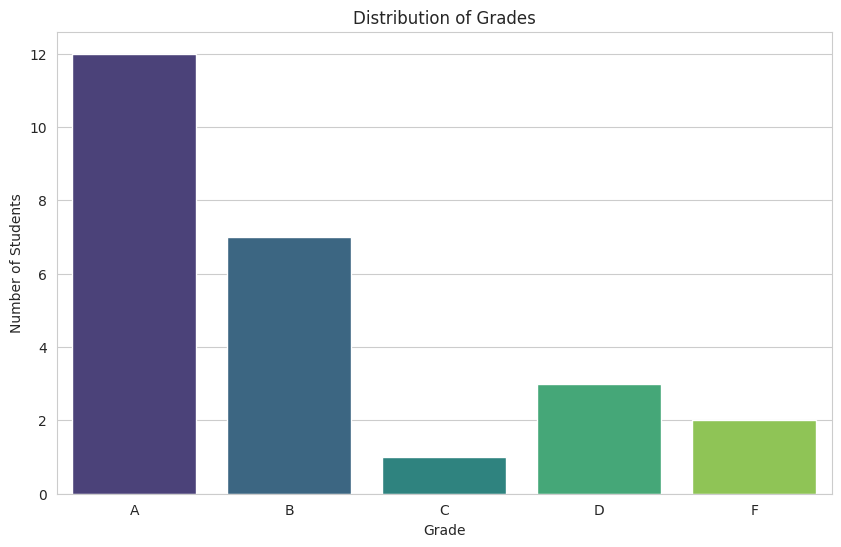

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
sns.set_style("whitegrid")

# Plot 1: Distribution of Grades
plt.figure(figsize=(10, 6))
sns.countplot(x='Grade', data=df_quiz_data, order=['A', 'B', 'C', 'D', 'F'], palette='viridis')
plt.title('Distribution of Grades')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()

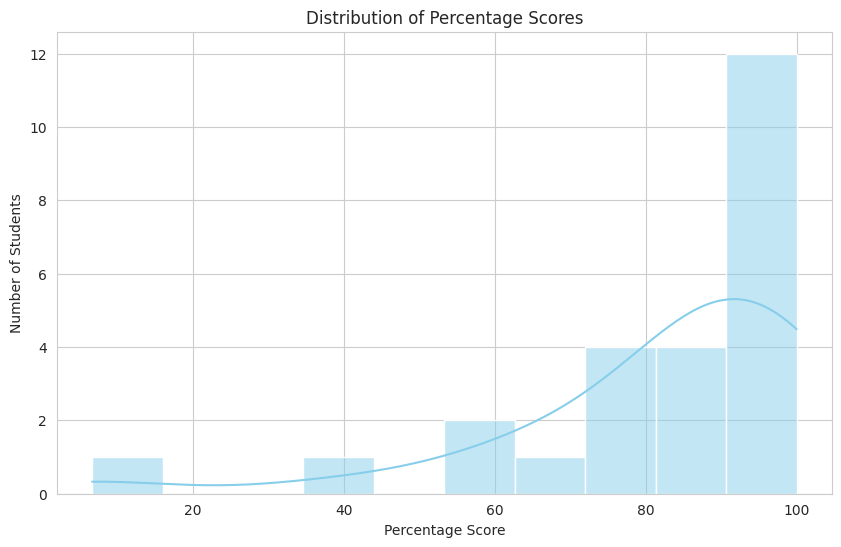

In [12]:
# Plot 2: Distribution of Percentage Scores
plt.figure(figsize=(10, 6))
sns.histplot(df_quiz_data['Percentage Score'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Percentage Scores')
plt.xlabel('Percentage Score')
plt.ylabel('Number of Students')
plt.show()

/tmp/ipykernel_960/3846799364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Percentage Score', data=top_performers, palette='coolwarm')


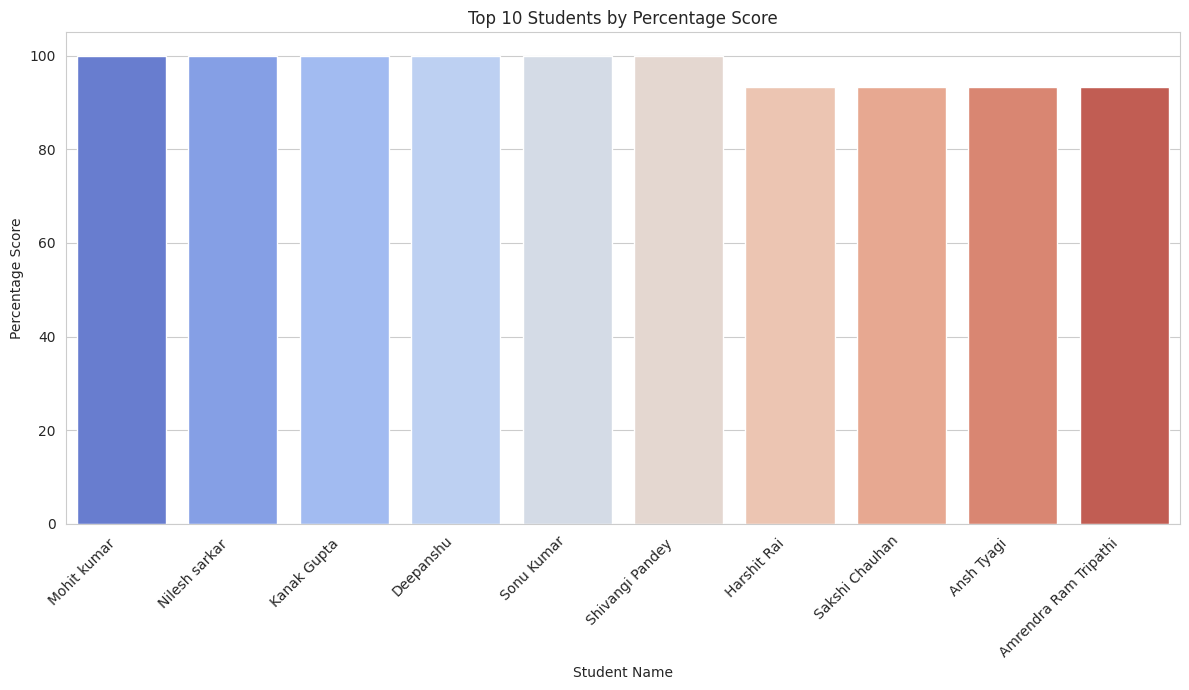

In [13]:
# Plot 3: Top 10 Students by Percentage Score
top_performers = df_quiz_data.sort_values(by='Percentage Score', ascending=False).head(10)
plt.figure(figsize=(12, 7))
sns.barplot(x='Name', y='Percentage Score', data=top_performers, palette='coolwarm')
plt.title('Top 10 Students by Percentage Score')
plt.xlabel('Student Name')
plt.ylabel('Percentage Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Addressing Other PDF Requirements:

Based on the problem statement, here's a summary of what has been addressed and what can be further considered:

1.  **Detect newly added quiz files:** The current setup processes a single file. For automated detection of multiple files, a more complex system (e.g., watching a directory, or processing a list of files) would be needed. If you have more quiz files, please provide them, and I can extend the code to combine them.
2.  **Combine student marks:** We have loaded and processed marks from one quiz file.
3.  **Calculating cumulative scores:** As only one quiz file is provided, cumulative scores across multiple quizzes are not applicable yet. This would require data from multiple quizzes.
4.  **Computing module-wise and overall percentiles:** Overall percentiles have been computed. Module-wise percentiles would require additional data indicating which questions belong to which modules.
5.  **Assigning grades:** Grades have been successfully assigned based on percentage scores.
6.  **Generating grade cards:** I will demonstrate generating a sample grade card for a student below.
7.  **Sending performance reports to students:** This functionality typically requires integration with email services (e.g., using Python libraries like `smtplib` or `sendgrid`) and is beyond the scope of direct notebook execution without user setup and credentials. We can generate the content for these reports, but not send them directly from here.

### Sample Grade Card Generation

Let's generate a simple text-based grade card for a specific student to illustrate how this could be done. You can choose any student's name from the `df_quiz_data['Name']` column.

In [14]:
def generate_grade_card(student_name, df):
    student_data = df[df['Name'] == student_name]
    if not student_data.empty:
        student_data = student_data.iloc[0] # Get the first row if multiple entries
        print(f"\n--- Grade Card for {student_data['Name']} ---")
        print(f"Username: {student_data['Username']}")
        print(f"Total Score: {student_data['Total score']}")
        print(f"Calculated Score: {student_data['Score']} out of {max_score}")
        print(f"Percentage Score: {student_data['Percentage Score']:.2f}%")
        print(f"Grade: {student_data['Grade']}")
        print(f"Percentile Rank: {student_data['Percentile Rank']:.2f}")
        print("-------------------------------------")
    else:
        print(f"Student '{student_name}' not found in the data.")

# Example: Generate a grade card for 'Jagat Kumar'
generate_grade_card('Jagat Kumar', df_quiz_data)

# You can pick another student, e.g., the top performer
top_student_name = df_quiz_data.sort_values(by='Percentage Score', ascending=False)['Name'].iloc[0]
print(f"\nGenerating grade card for a top performer: {top_student_name}")
generate_grade_card(top_student_name, df_quiz_data)


--- Grade Card for Jagat Kumar ---
Username: jagat.kumar@liet.in
Total Score: 6.00 / 15
Calculated Score: 6.0 out of 15.0
Percentage Score: 40.00%
Grade: F
Percentile Rank: 8.00
-------------------------------------

Generating grade card for a top performer: Mohit kumar 

--- Grade Card for Mohit kumar  ---
Username: mohitkumar746185@gmail.com
Total Score: 15.00 / 15
Calculated Score: 15.0 out of 15.0
Percentage Score: 100.00%
Grade: A
Percentile Rank: 90.00
-------------------------------------


The extracted text is available in the `text_content` variable. You can modify the last cell to process or display the full content as needed.